# Task 4 – Intermediate Level Analysis

# Objective

Analyze employee attrition patterns using feature engineering, exploratory data analysis, and correlation analysis to identify factors associated with employee turnover.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset

df = pd.read_csv("bank_employee_attrition.csv")

# Display first 5 rows

df.head()

,MMMM_YY,Employee_ID,Age,Gender,City,Education_Level,Department,Income,Date_Of_Joining,LastWorkingDate,Joining_Designation,Grade,Total_Business_Value,Quarterly_Rating,Overtime_Flag
0,Jan-21,10001,29.0,0,BLR,1,Operations,64380.0,17-08-2018,21-08-2021,Analyst,C,11806,2.0,0
1,Feb-21,10001,29.0,0,BLR,1,Operations,64380.0,17-08-2018,21-08-2021,Analyst,C,16644,1.0,0
2,Mar-21,10001,29.0,0,BLR,1,Operations,64380.0,17-08-2018,21-08-2021,Analyst,C,26253,3.0,1
3,Apr-21,10001,29.0,0,BLR,1,Operations,64380.0,17-08-2018,21-08-2021,Analyst,C,-12414,1.0,1
4,May-21,10001,29.0,0,BLR,1,Operations,64380.0,17-08-2018,21-08-2021,Analyst,C,39153,2.0,0


In [5]:
# Convert date columns into datetime format

df['Date_Of_Joining'] = pd.to_datetime(df['Date_Of_Joining'])

df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'])

df['MMMM_YY'] = pd.to_datetime(df['MMMM_YY'], format='%b-%y')

# Q6. Create Attrition Column

In [6]:
# Create Attrition column

df['Attrition'] = np.where(df['LastWorkingDate'].notna(), 1, 0)

df['Attrition'].value_counts()

Attrition
0    9288
1    1528
Name: count, dtype: int64

In [7]:
# Calculate attrition rate

attrition_rate = (df['Attrition'].mean()) * 100

print("Attrition Rate:", round(attrition_rate,2), "%")

Attrition Rate: 14.13 %


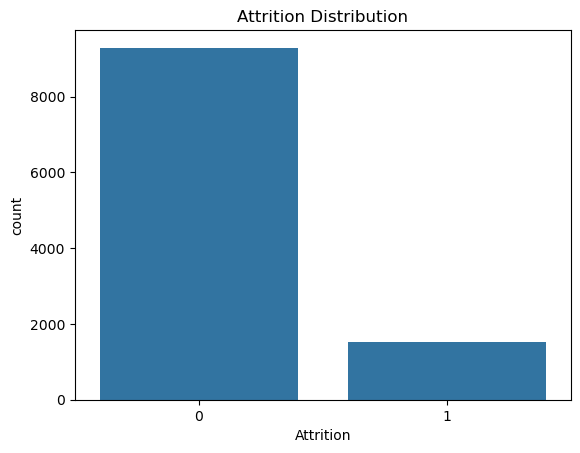

In [8]:
# Visualize attrition distribution

sns.countplot(x='Attrition', data=df)

plt.title("Attrition Distribution")

plt.show()

# Insights

- Majority of employees stayed with the bank.
- Only a small percentage of employees left the organization.
- The attrition rate is approximately 14.13%.

# Q7. Tenure Analysis

In [11]:
# Calculate tenure in months

df['Tenure_Months'] = (
    (df['MMMM_YY'].dt.year - df['Date_Of_Joining'].dt.year) * 12
    +
    (df['MMMM_YY'].dt.month - df['Date_Of_Joining'].dt.month)
)

df[['Employee_ID','Tenure_Months']].head()

,Employee_ID,Tenure_Months
0,10001,29
1,10001,30
2,10001,31
3,10001,32
4,10001,33


In [12]:
# Calculate average tenure

df['Tenure_Months'].mean()

np.float64(26.82451923076923)

In [13]:
# Create tenure categories

bins = [0,6,12,24,100]

labels = ['0-6 Months',
          '6-12 Months',
          '12-24 Months',
          '24+ Months']

df['Tenure_Band'] = pd.cut(
    df['Tenure_Months'],
    bins=bins,
    labels=labels
)

In [14]:
# Attrition rate by tenure band

tenure_attrition = df.groupby('Tenure_Band')['Attrition'].mean()*100

tenure_attrition

C:\Users\Muneeza\AppData\Local\Temp\ipykernel_6372\1162985785.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_attrition = df.groupby('Tenure_Band')['Attrition'].mean()*100


Tenure_Band
0-6 Months      17.268446
6-12 Months     15.301086
12-24 Months    13.549286
24+ Months      13.707680
Name: Attrition, dtype: float64

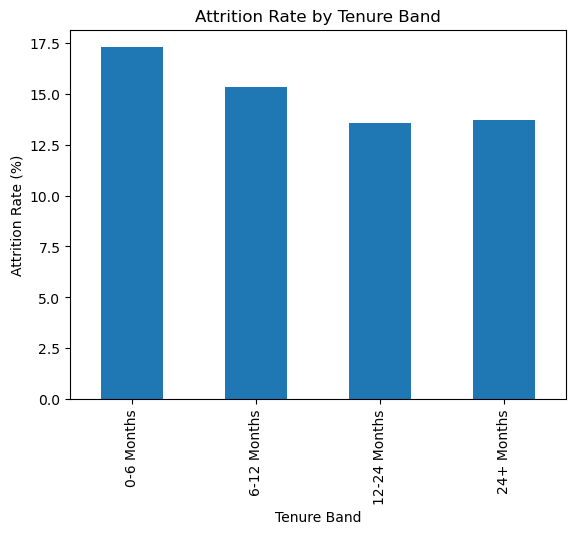

In [15]:
tenure_attrition.plot(kind='bar')

plt.title("Attrition Rate by Tenure Band")

plt.xlabel("Tenure Band")

plt.ylabel("Attrition Rate (%)")

plt.show()

# Insights

- Employees in the 0–6 Months tenure band have the highest attrition rate.
- Attrition rate decreases as employee tenure increases.
- Employees with 12+ months of tenure show relatively lower attrition.

# Q8. Rating and Income Growth Analysis

In [17]:
# Sort values first

df = df.sort_values(
    ['Employee_ID','MMMM_YY']
)

# Previous rating

df['Previous_Rating'] = (
    df.groupby('Employee_ID')
      ['Quarterly_Rating']
      .shift(1)
)

# Rating increase flag

df['Rating_Increased'] = np.where(
    df['Quarterly_Rating'] >
    df['Previous_Rating'],
    1,
    0
)

In [36]:
# Show created rating-related columns

df[[
    'Employee_ID',
    'Quarterly_Rating',
    'Previous_Rating',
    'Rating_Increased'
]].head()

,Employee_ID,Quarterly_Rating,Previous_Rating,Rating_Increased
0,10001,2.0,NaN,0
1,10001,1.0,2.0,0
2,10001,3.0,1.0,1
3,10001,1.0,3.0,0
4,10001,2.0,1.0,1


In [18]:
# Previous income

df['Previous_Income'] = (
    df.groupby('Employee_ID')
      ['Income']
      .shift(1)
)

# Income increase flag

df['Income_Increased'] = np.where(
    df['Income'] >
    df['Previous_Income'],
    1,
    0
)

In [37]:
# Show created income-related columns

df[[
    'Employee_ID',
    'Income',
    'Previous_Income',
    'Income_Increased'
]].head()

,Employee_ID,Income,Previous_Income,Income_Increased
0,10001,64380.0,NaN,0
1,10001,64380.0,64380.0,0
2,10001,64380.0,64380.0,0
3,10001,64380.0,64380.0,0
4,10001,64380.0,64380.0,0


In [19]:
# Percentage of Employees with Improved Ratings

rating_improved = (
    df['Rating_Increased'].mean()
) * 100

print(
    round(rating_improved,2)
)

31.07


In [20]:
# Correlation Between Rating and Income Increase

df[
 ['Rating_Increased',
  'Income_Increased']
].corr()

,Rating_Increased,Income_Increased
Rating_Increased,1.000000,0.026942
Income_Increased,0.026942,1.000000


# Insights

- Around 31.07% of employees showed an improvement in ratings.
- The correlation between rating increase and income increase is very weak.
- Higher ratings do not necessarily lead to higher income growth.

# Q9. Distribution of Age and Income

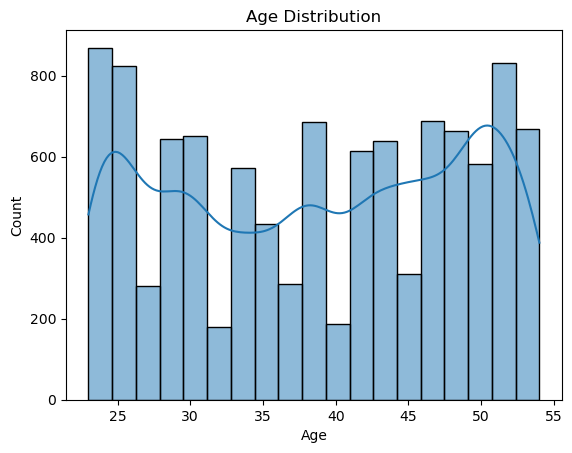

In [22]:
# Age Distribution

sns.histplot(df['Age'], kde=True)

plt.title("Age Distribution")

plt.show()

# Insights

- Employee ages are distributed between approximately 24 and 54 years.
- Most employees belong to the middle-age workforce group.
- The age distribution appears fairly balanced with no extreme skewness.

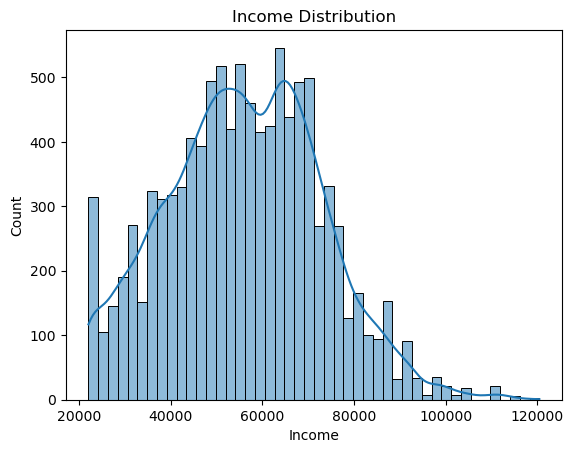

In [23]:
# Income Distribution

sns.histplot(df['Income'], kde=True)

plt.title("Income Distribution")

plt.show()

# Insights

- Most employees have incomes in the middle income range.
- The income distribution is approximately normal.
- Very high and very low income values are less common.

# Q10. Attrition Rate by Department

In [24]:
# Calculate attrition rate (%) for each department

dept_attrition = (
    df.groupby('Department')
    ['Attrition']
    .mean()*100
)

dept_attrition

Department
Corporate Banking    14.792899
HR & Admin           22.395210
IT & Digital         12.488605
Operations           14.518002
Retail Banking       11.366081
Risk & Compliance    14.285714
Name: Attrition, dtype: float64

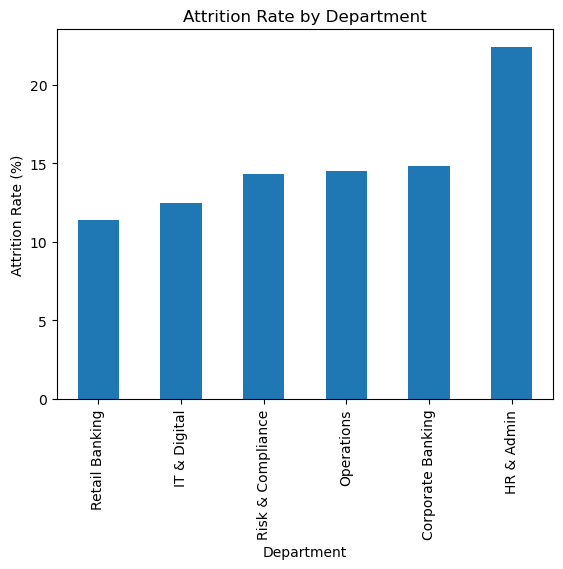

In [25]:
# Plot attrition rate by department

dept_attrition.sort_values().plot(
    kind='bar'
)

plt.title(
    "Attrition Rate by Department"
)

plt.xlabel("Department")

plt.ylabel(
    "Attrition Rate (%)"
)

plt.show()

In [26]:
# Identify departments with highest and lowest attrition rates

print(
    "Highest:",
    dept_attrition.idxmax()
)

print(
    "Lowest:",
    dept_attrition.idxmin()
)

Highest: HR & Admin
Lowest: Retail Banking


# Insights

- HR & Admin has the highest attrition rate among all departments.
- Retail Banking has the lowest attrition rate.
- Attrition rates vary across departments, indicating different employee retention patterns.

# Q11. Quarterly Rating vs Attrition

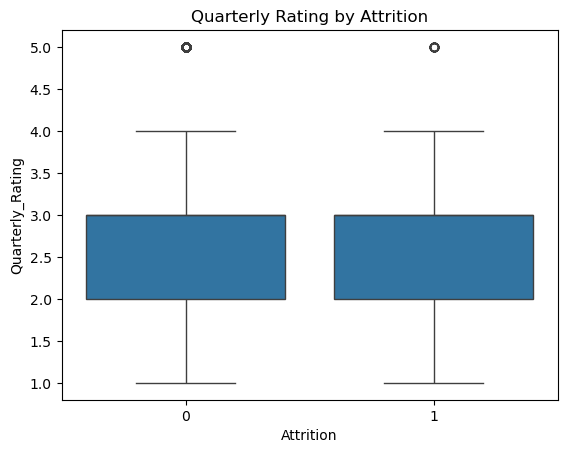

In [27]:
# Compare quarterly ratings between attrition groups

sns.boxplot(
    x='Attrition',
    y='Quarterly_Rating',
    data=df
)

plt.title(
    "Quarterly Rating by Attrition"
)

plt.show()

# Insights

- Quarterly ratings are similar for both attrition groups.
- No major difference is observed in rating distributions.
- Employee attrition does not appear to be strongly related to quarterly ratings.

# Q12. Monthly Attrition Trend

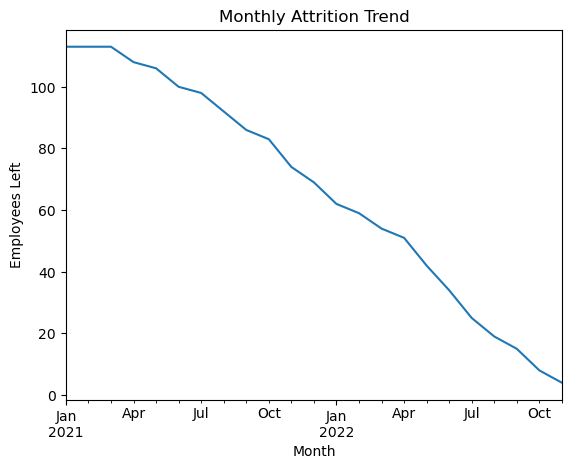

In [29]:
# Calculate monthly attrition trend

monthly_attrition = (
    df[df['Attrition'] == 1]
    .groupby('MMMM_YY')
    .size()
)

monthly_attrition.plot()

plt.title(
    "Monthly Attrition Trend"
)

plt.xlabel("Month")

plt.ylabel(
    "Employees Left"
)

plt.show()

# Insights

- Employee attrition shows a decreasing trend over time.
- The number of employees leaving the organization reduced gradually across months.
- Attrition was higher in the earlier months and lower in the later months.

# Q13. Treatment of Missing Values in LastWorkingDate

In [31]:
# Explain why LastWorkingDate should not be imputed

print(
    "Missing LastWorkingDate means employee is still active."
)

print(
    "Therefore, this column should not be imputed."
)

Missing LastWorkingDate means employee is still active.
Therefore, this column should not be imputed.


# Insights

- Null values in LastWorkingDate are meaningful.
- They indicate employees who are still active.
- Imputing these values would create incorrect attrition information.

# Q14. Correlation Between Age and Income

In [32]:
# Calculate correlation between age and income

correlation = df['Age'].corr(
    df['Income']
)

print(
    "Correlation:",
    round(correlation, 3)
)

Correlation: 0.017


# Insights

- Age and income have a very weak positive correlation.
- There is almost no linear relationship between age and income.
- Employee age alone does not significantly influence income.

# Q15. Education Level vs Business Value

In [33]:
# Calculate average business value by education level

education_business = (
    df.groupby('Education_Level')
    ['Total_Business_Value']
    .mean()
)

education_business

Education_Level
0    74578.279597
1    65006.822476
2    72289.994903
Name: Total_Business_Value, dtype: float64

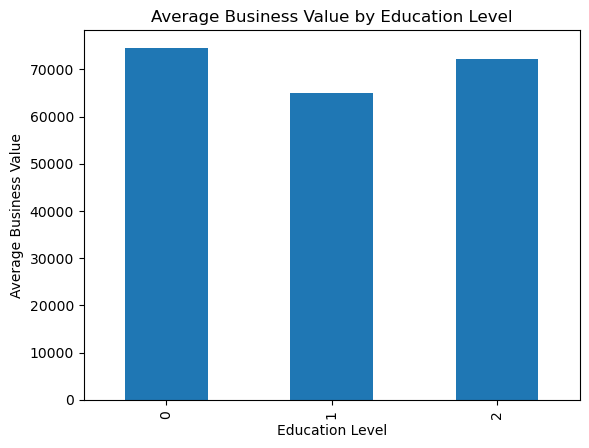

In [34]:
# Visualize average business value by education level

education_business.plot(
    kind='bar'
)

plt.title(
    "Average Business Value by Education Level"
)

plt.xlabel(
    "Education Level"
)

plt.ylabel(
    "Average Business Value"
)

plt.show()

# Insights

- Education Level 0 has the highest average business value.
- Education Level 1 has the lowest average business value.
- Average business value varies across education levels, but the differences are not very large.

# Conclusion

- Attrition patterns were analysed using multiple employee factors.
- Tenure, department, ratings, income growth, and education were evaluated.
- Attrition trends and workforce characteristics were identified.
- Correlation analysis helped understand relationships between variables.
- Findings can support employee retention strategies and HR decision-making.